In [30]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [31]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [32]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y

In [33]:
df.shape

(100, 6)

In [34]:
df.head()

,col1,col2,col3,col4,col5,target
0,1.603999,-3.187317,-2.552627,3.133386,3.875770,1
1,4.165660,-0.262209,-0.290450,0.894695,0.921867,1
2,0.310572,1.466616,-1.262120,1.072331,-2.658790,0
3,0.612260,2.262937,1.727973,0.922673,0.477884,1
4,2.487428,-0.994859,-2.063398,-0.089858,3.758056,1


In [35]:
# function for row sampling
def row_sampling(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [36]:
# function for feature sampling
def sample_features(df,percent):
    n_features = int(percent * (df.shape[1] - 1))  # exclude target
    cols = df.columns[:-1].to_series().sample(n=n_features)
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

In [37]:
# feature for combined sampling
def combined_sampling(df,row_percent,col_percent):
    new_df=row_sampling(df,row_percent)
    return sample_features(new_df,col_percent)

# by using row_sampling

In [38]:
df1=row_sampling(df,0.2)
df2=row_sampling(df,0.2)
df3=row_sampling(df,0.2)


In [39]:

from sklearn.tree import DecisionTreeClassifier

clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [40]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[4] <= 0.562\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.4, 0.5, 'x[2] <= 3.27\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.7, 0.6666666666666667, '  False')]

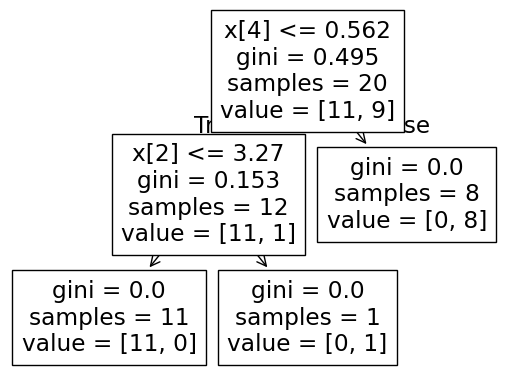

In [42]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[4] <= -0.01\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.625, 0.5, '  False')]

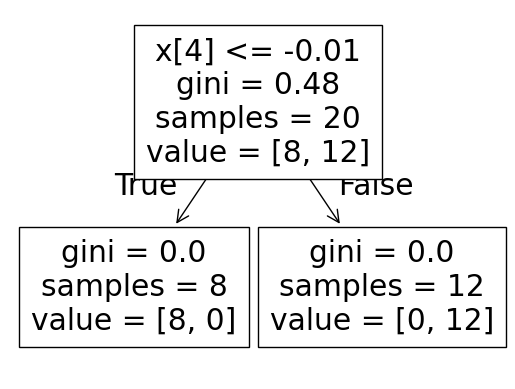

In [43]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[3] <= -0.876\ngini = 0.42\nsamples = 20\nvalue = [14, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= -0.943\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]')]

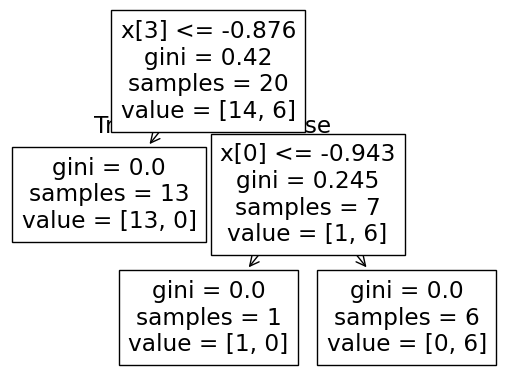

In [44]:
plot_tree(clf3)

In [45]:
df1

,col1,col2,col3,col4,col5,target
6,0.903333,1.555545,1.088204,1.112678,1.079496,1
32,-0.163760,0.894803,-1.242616,0.349019,-2.704952,0
33,0.651386,1.308287,-2.054539,-1.049759,-0.878130,0
4,2.487428,-0.994859,-2.063398,-0.089858,3.758056,1
74,-1.037901,-1.081980,-0.518318,-0.668201,-0.513676,0
84,-1.900927,-0.927323,-3.015371,-2.234552,-2.624363,0
10,-0.728779,5.784147,5.324576,-0.575676,-2.316364,1
34,-1.292385,-4.089918,1.214614,-2.967852,-1.822559,0
29,3.750320,-1.299973,-1.745194,0.302746,2.946665,1
1,4.165660,-0.262209,-0.290450,0.894695,0.921867,1


In [46]:
clf1.predict(np.array([0.772825	,1.514430	,-1.001032	,-1.213433	,-2.654905]).reshape(1,5))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [47]:
clf2.predict(np.array([0.772825	,1.514430	,-1.001032	,-1.213433	,-2.654905]).reshape(1,5))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [48]:
clf3.predict(np.array([0.772825	,1.514430	,-1.001032	,-1.213433	,-2.654905]).reshape(1,5))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

# by using column sampling

In [51]:
df4=sample_features(df,0.8)
df5=sample_features(df,0.8)
df6=sample_features(df,0.8)

C:\Users\hp\AppData\Local\Temp\ipykernel_3164\2044277880.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\hp\AppData\Local\Temp\ipykernel_3164\2044277880.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\hp\AppData\Local\Temp\ipykernel_3164\2044277880.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [53]:
df4.shape

(100, 5)

In [60]:
clf1.fit(df4.iloc[:,0:4],df4.iloc[:,-1]) 
clf2.fit(df5.iloc[:,0:4],df5.iloc[:,-1])
clf3.fit(df6.iloc[:,0:4],df6.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [61]:
df4

,col3,col2,col5,col4,target
0,-2.552627,-3.187317,3.875770,3.133386,1
1,-0.290450,-0.262209,0.921867,0.894695,1
2,-1.262120,1.466616,-2.658790,1.072331,0
3,1.727973,2.262937,0.477884,0.922673,1
4,-2.063398,-0.994859,3.758056,-0.089858,1
...,...,...,...,...,...
95,1.536592,1.653147,0.431128,-1.127447,1
96,-3.308222,-2.227878,5.356322,0.394792,1
97,3.402874,2.980574,-0.979979,0.734149,1
98,1.810518,1.525213,1.049521,0.390493,1


[Text(0.3392857142857143, 0.9166666666666666, 'x[2] <= -0.01\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.14285714285714285, 0.75, 'x[0] <= 1.952\ngini = 0.265\nsamples = 51\nvalue = [43, 8]'),
 Text(0.24107142857142858, 0.8333333333333333, 'True  '),
 Text(0.07142857142857142, 0.5833333333333334, 'gini = 0.0\nsamples = 43\nvalue = [43, 0]'),
 Text(0.21428571428571427, 0.5833333333333334, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.5357142857142857, 0.75, 'x[3] <= -1.154\ngini = 0.245\nsamples = 49\nvalue = [7, 42]'),
 Text(0.4375, 0.8333333333333333, '  False'),
 Text(0.35714285714285715, 0.5833333333333334, 'x[1] <= 0.418\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.2857142857142857, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7142857142857143, 0.5833333333333334, 'x[0] <= -2.63\ngini = 0.162\nsamples = 45\nvalue = [4, 41]'),
 Text(0.57142

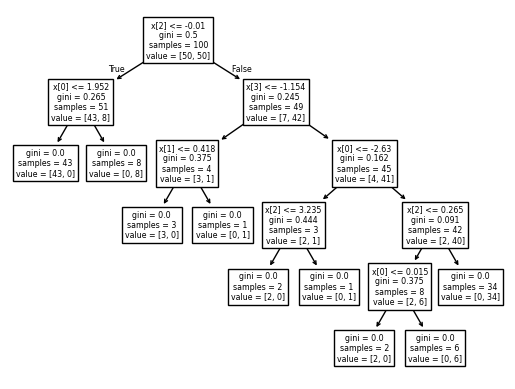

In [62]:
plot_tree(clf1)

[Text(0.3392857142857143, 0.9166666666666666, 'x[2] <= -0.01\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.14285714285714285, 0.75, 'x[3] <= 1.952\ngini = 0.265\nsamples = 51\nvalue = [43, 8]'),
 Text(0.24107142857142858, 0.8333333333333333, 'True  '),
 Text(0.07142857142857142, 0.5833333333333334, 'gini = 0.0\nsamples = 43\nvalue = [43, 0]'),
 Text(0.21428571428571427, 0.5833333333333334, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.5357142857142857, 0.75, 'x[1] <= -1.154\ngini = 0.245\nsamples = 49\nvalue = [7, 42]'),
 Text(0.4375, 0.8333333333333333, '  False'),
 Text(0.35714285714285715, 0.5833333333333334, 'x[0] <= 0.418\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.2857142857142857, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7142857142857143, 0.5833333333333334, 'x[3] <= -2.63\ngini = 0.162\nsamples = 45\nvalue = [4, 41]'),
 Text(0.57142

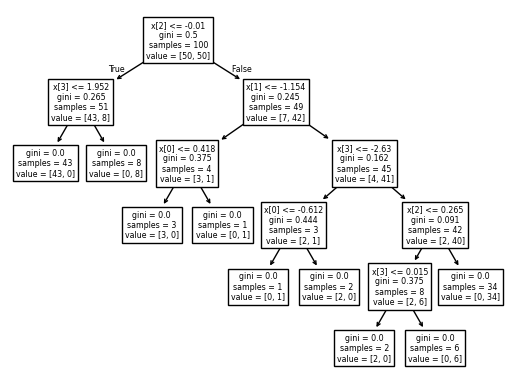

In [63]:
plot_tree(clf2)

[Text(0.38235294117647056, 0.9166666666666666, 'x[3] <= -0.01\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.11764705882352941, 0.75, 'x[0] <= 1.656\ngini = 0.265\nsamples = 51\nvalue = [43, 8]'),
 Text(0.25, 0.8333333333333333, 'True  '),
 Text(0.058823529411764705, 0.5833333333333334, 'gini = 0.0\nsamples = 42\nvalue = [42, 0]'),
 Text(0.17647058823529413, 0.5833333333333334, 'x[3] <= -0.096\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.11764705882352941, 0.4166666666666667, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.23529411764705882, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6470588235294118, 0.75, 'x[1] <= -0.056\ngini = 0.245\nsamples = 49\nvalue = [7, 42]'),
 Text(0.5147058823529411, 0.8333333333333333, '  False'),
 Text(0.4117647058823529, 0.5833333333333334, 'x[0] <= 1.11\ngini = 0.494\nsamples = 9\nvalue = [5, 4]'),
 Text(0.35294117647058826, 0.4166666666666667, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.4705882

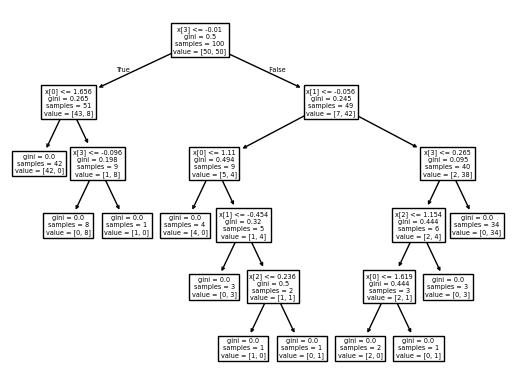

In [64]:
plot_tree(clf3)

In [66]:
clf1.predict(np.array([-1.262120	,1.466616	,-2.658790	,1.072331]).reshape(1,4))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

# by combined sampling

In [67]:
df7=combined_sampling(df,0.5,0.5)
df8=combined_sampling(df,0.5,0.5)
df9=combined_sampling(df,0.5,0.5)

C:\Users\hp\AppData\Local\Temp\ipykernel_3164\2044277880.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\hp\AppData\Local\Temp\ipykernel_3164\2044277880.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']
C:\Users\hp\AppData\Local\Temp\ipykernel_3164\2044277880.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [68]:
df7

,col1,col5,target
42,-0.656467,1.526093,1
24,-1.140905,-2.427947,0
40,0.805024,1.722991,1
1,4.165660,0.921867,1
72,1.973253,3.112348,1
69,1.489186,0.228476,1
38,-0.990925,-3.415959,0
24,-1.140905,-2.427947,0
7,-1.584875,-3.339867,0
14,2.134897,-1.367405,0


In [69]:
df7.shape

(50, 3)

In [75]:
clf1.fit(df7.iloc[:,0:2],df7.iloc[:,-1])
clf2.fit(df8.iloc[:,0:2],df8.iloc[:,-1])
clf3.fit(df9.iloc[:,0:2],df9.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.6, 0.8333333333333334, 'x[1] <= 0.22\ngini = 0.461\nsamples = 50\nvalue = [32, 18]'),
 Text(0.4, 0.5, 'x[0] <= 2.184\ngini = 0.059\nsamples = 33\nvalue = [32, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 32\nvalue = [32, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.7, 0.6666666666666667, '  False')]

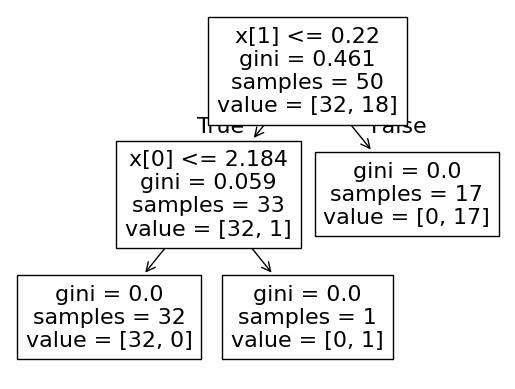

In [76]:
plot_tree(clf1)

[Text(0.6666666666666666, 0.9166666666666666, 'x[1] <= 0.728\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.5, 0.75, 'x[0] <= 1.174\ngini = 0.367\nsamples = 33\nvalue = [25, 8]'),
 Text(0.5833333333333333, 0.8333333333333333, 'True  '),
 Text(0.3333333333333333, 0.5833333333333334, 'x[1] <= 0.011\ngini = 0.137\nsamples = 27\nvalue = [25, 2]'),
 Text(0.16666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.5, 0.4166666666666667, 'x[0] <= -0.8\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6666666666666666, 0.25, 'x[1] <= 0.565\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.5, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8333333333333334, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.5833333333333334, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.8333333333333334, 0.75, 'gin

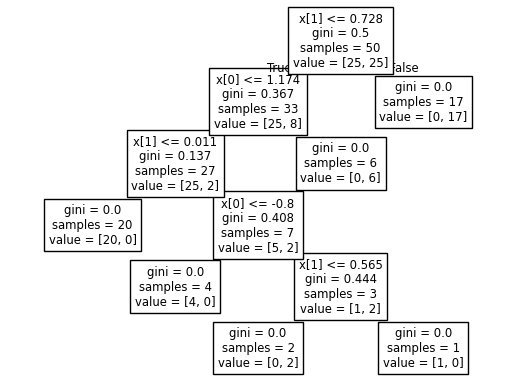

In [77]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[1] <= 0.752\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.4, 0.5, 'x[0] <= 1.293\ngini = 0.293\nsamples = 28\nvalue = [23, 5]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.7, 0.6666666666666667, '  False')]

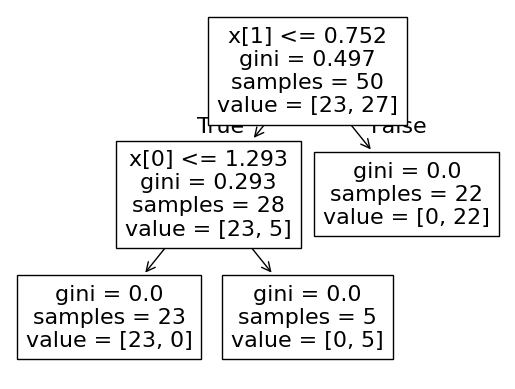

In [78]:
plot_tree(clf3)

In [79]:
clf1.predict(np.array([	-0.858176	,1.049521]).reshape(1,2))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [80]:
clf2.predict(np.array([	-0.858176	,1.049521]).reshape(1,2))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [81]:
clf3.predict(np.array([	-0.858176	,1.049521]).reshape(1,2))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])